# BBB Prediction Model Performance Metrics & Analysis - Part 2

Analysis of newly trained models with improved data handling (8020 split with undersampling).

This notebook provides comprehensive analysis of all hypertuned models including:
- Model performance metrics comparison
- ROC-AUC curves (individual plots for legibility)
- Confusion matrices (individual plots)
- Trial stability analysis (5 random splits)
- Comprehensive summary report

## 1. Import Libraries and Load Data

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix,
    matthews_corrcoef, classification_report
)
import plotly.graph_objects as go
import plotly.express as px

warnings.filterwarnings('ignore')

# Set random seed for reproducibility (same as training)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Set plotting style for better legibility
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 12

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [2]:
# Utility functions
def load_split(split_ratio: str = '8020', base_dir: str = '../data/split'):
    base_path = Path(base_dir) / split_ratio
    X_train = pd.read_csv(base_path / 'x_train.csv', index_col=0).select_dtypes(include=[np.number])
    y_train = pd.read_csv(base_path / 'y_train.csv', index_col=0).iloc[:, 0]
    X_test = pd.read_csv(base_path / 'x_test.csv', index_col=0).select_dtypes(include=[np.number])
    y_test = pd.read_csv(base_path / 'y_test.csv', index_col=0).iloc[:, 0]
    return X_train, y_train, X_test, y_test

def compute_all_metrics(y_true, y_pred, y_proba=None):
    """Compute comprehensive evaluation metrics."""
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    else:
        tn, fp, fn, tp = 0, 0, 0, 0
        sensitivity = specificity = 0.0
    
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': np.mean([sensitivity, specificity]),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'sensitivity': sensitivity,
        'specificity': specificity,
        'mcc': matthews_corrcoef(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan,
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp)
    }
    return metrics

print('✅ Utility functions defined')

✅ Utility functions defined


In [3]:
# Load 8020 split data
X_train, y_train, X_test, y_test = load_split('8020')

print("="*70)
print("80/20 TRAIN-TEST SPLIT LOADED (CORRECTED DATA)")
print("="*70)
print(f"Train: {X_train.shape[0]} samples ({(y_train==1).sum()} pos, {(y_train==0).sum()} neg)")
print(f"Test:  {X_test.shape[0]} samples ({(y_test==1).sum()} pos, {(y_test==0).sum()} neg)")
print(f"Features: {X_train.shape[1]}")
print(f"Train imbalance ratio: {(y_train==0).sum() / (y_train==1).sum():.2f}:1")
print()

80/20 TRAIN-TEST SPLIT LOADED (CORRECTED DATA)
Train: 7570 samples (5372 pos, 2198 neg)
Test:  1893 samples (1343 pos, 550 neg)
Features: 933
Train imbalance ratio: 0.41:1



## 2. Load Newly Trained Hypertuned Models

In [4]:
# Load all hypertuned models from hypertuning directory
model_names = ['LogReg', 'KNN', 'RF', 'ET', 'XGB', 'LGBM']
models = {}

print("="*70)
print("LOADING HYPERTUNED MODELS (8020 SPLIT WITH UNDERSAMPLING)")
print("="*70)

for model_name in model_names:
    try:
        model_path = f'../output/models/hypertuning/{model_name}_8020_best_model.pkl'
        models[model_name] = joblib.load(model_path)
        print(f'✅ Loaded {model_name} model')
    except Exception as e:
        print(f'❌ Could not load {model_name}: {e}')

print(f'\n✅ Successfully loaded {len(models)} models: {list(models.keys())}')
print()

LOADING HYPERTUNED MODELS (8020 SPLIT WITH UNDERSAMPLING)
✅ Loaded LogReg model
✅ Loaded KNN model
✅ Loaded RF model
✅ Loaded ET model
✅ Loaded XGB model
✅ Loaded LGBM model

✅ Successfully loaded 6 models: ['LogReg', 'KNN', 'RF', 'ET', 'XGB', 'LGBM']



## 3. Load Results and Calculate Metrics

In [5]:
# Load results from hypertuning
df_results = pd.read_csv('../output/models/hypertuning/results_8020_hypertuned.csv')

print("="*100)
print("FINAL RESULTS: 80/20 SPLIT WITH UNDERSAMPLING")
print("="*100)

# Display results
display_cols = ['model', 'accuracy', 'balanced_accuracy', 'f1', 'precision', 'recall', 
                'roc_auc', 'mcc', 'sensitivity', 'specificity']
df_display = df_results[display_cols].copy()
df_display = df_display.sort_values('roc_auc', ascending=False)

print("\n📊 Model Performance Summary (sorted by ROC-AUC):\n")
display(df_display)

# Rename columns for consistency
df_results = df_results.rename(columns={'model': 'Model'})

print("\n" + "="*100)
print("MODEL RANKING BY ROC-AUC")
print("="*100)

ranking = df_results[['Model', 'balanced_accuracy', 'f1', 'roc_auc', 'mcc']].sort_values('roc_auc', ascending=False)
for idx, row in ranking.iterrows():
    print(f"{row['Model']:10} | Balanced Acc: {row['balanced_accuracy']:.4f} | F1: {row['f1']:.4f} | ROC-AUC: {row['roc_auc']:.4f}")

print()

FINAL RESULTS: 80/20 SPLIT WITH UNDERSAMPLING

📊 Model Performance Summary (sorted by ROC-AUC):



,model,accuracy,balanced_accuracy,f1,precision,recall,roc_auc,mcc,sensitivity,specificity
0,ET,0.856841,0.860994,0.894016,0.941516,0.851080,0.907543,0.683448,0.851080,0.870909
1,RF,0.851030,0.855825,0.889412,0.939519,0.844378,0.906865,0.672157,0.844378,0.867273
2,XGB,0.854200,0.859133,0.891850,0.941274,0.847357,0.906510,0.678834,0.847357,0.870909
3,LGBM,0.849445,0.852025,0.888541,0.935750,0.845867,0.906296,0.666466,0.845867,0.858182
4,KNN,0.841521,0.840535,0.882995,0.927109,0.842889,0.884807,0.646203,0.842889,0.838182
5,LogReg,0.806656,0.807375,0.855336,0.911542,0.805659,0.876370,0.577152,0.805659,0.809091



MODEL RANKING BY ROC-AUC
ET         | Balanced Acc: 0.8610 | F1: 0.8940 | ROC-AUC: 0.9075
RF         | Balanced Acc: 0.8558 | F1: 0.8894 | ROC-AUC: 0.9069
XGB        | Balanced Acc: 0.8591 | F1: 0.8919 | ROC-AUC: 0.9065
LGBM       | Balanced Acc: 0.8520 | F1: 0.8885 | ROC-AUC: 0.9063
KNN        | Balanced Acc: 0.8405 | F1: 0.8830 | ROC-AUC: 0.8848
LogReg     | Balanced Acc: 0.8074 | F1: 0.8553 | ROC-AUC: 0.8764



## 4. Individual Model Performance Metrics Visualizations

Creating separate plots for each metric for maximum legibility and clarity.

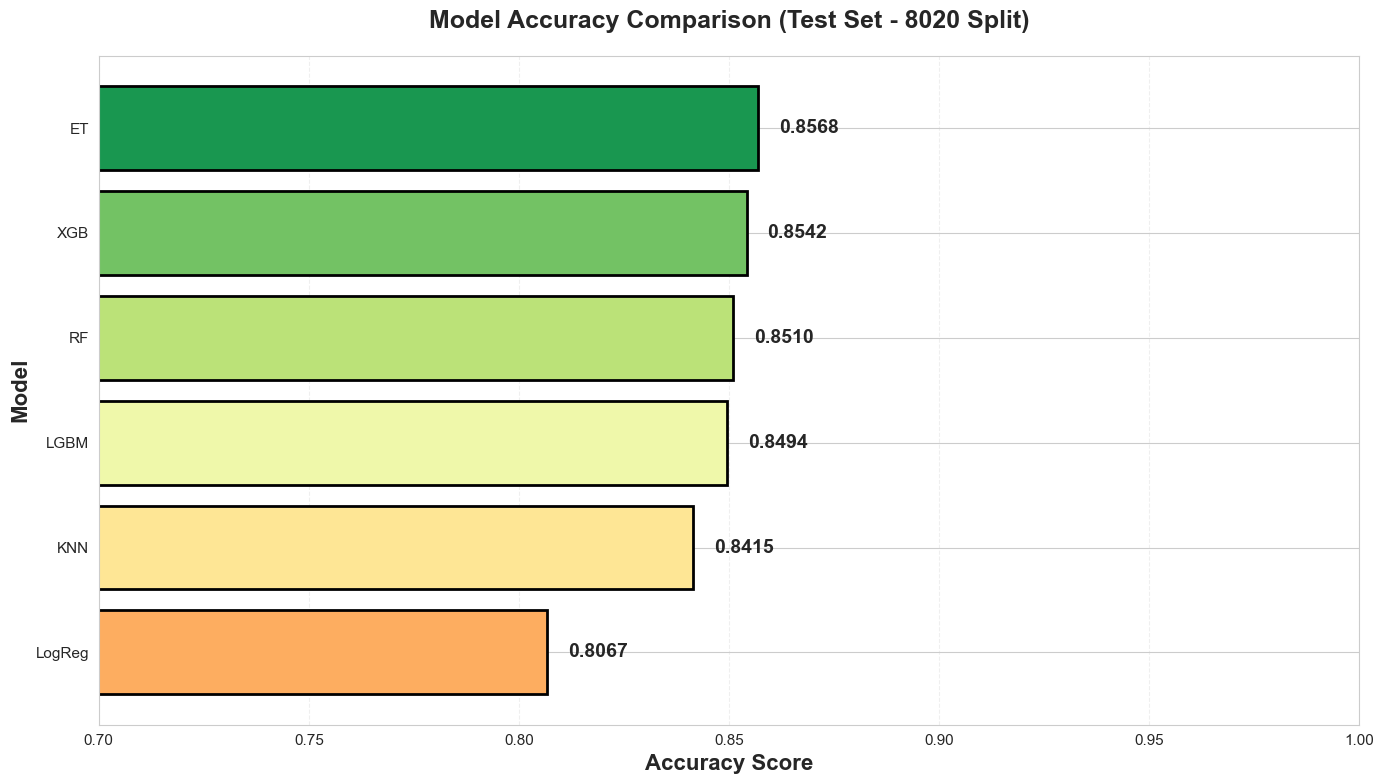

✅ Accuracy plot saved


In [6]:
# Create individual plots for each metric - Accuracy
plt.figure(figsize=(14, 8))

plot_df = df_results.sort_values('accuracy', ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(plot_df)))
bars = plt.barh(plot_df['Model'], plot_df['accuracy'], color=colors, edgecolor='black', linewidth=2)

plt.xlabel('Accuracy Score', fontweight='bold', fontsize=16)
plt.ylabel('Model', fontweight='bold', fontsize=16)
plt.title('Model Accuracy Comparison (Test Set - 8020 Split)', fontweight='bold', fontsize=18, pad=20)
plt.xlim(0.7, 1.0)
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels with better positioning
for i, (bar, val) in enumerate(zip(bars, plot_df['accuracy'])):
    plt.text(val + 0.005, i, f'{val:.4f}', va='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/metrics_part2_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ Accuracy plot saved')

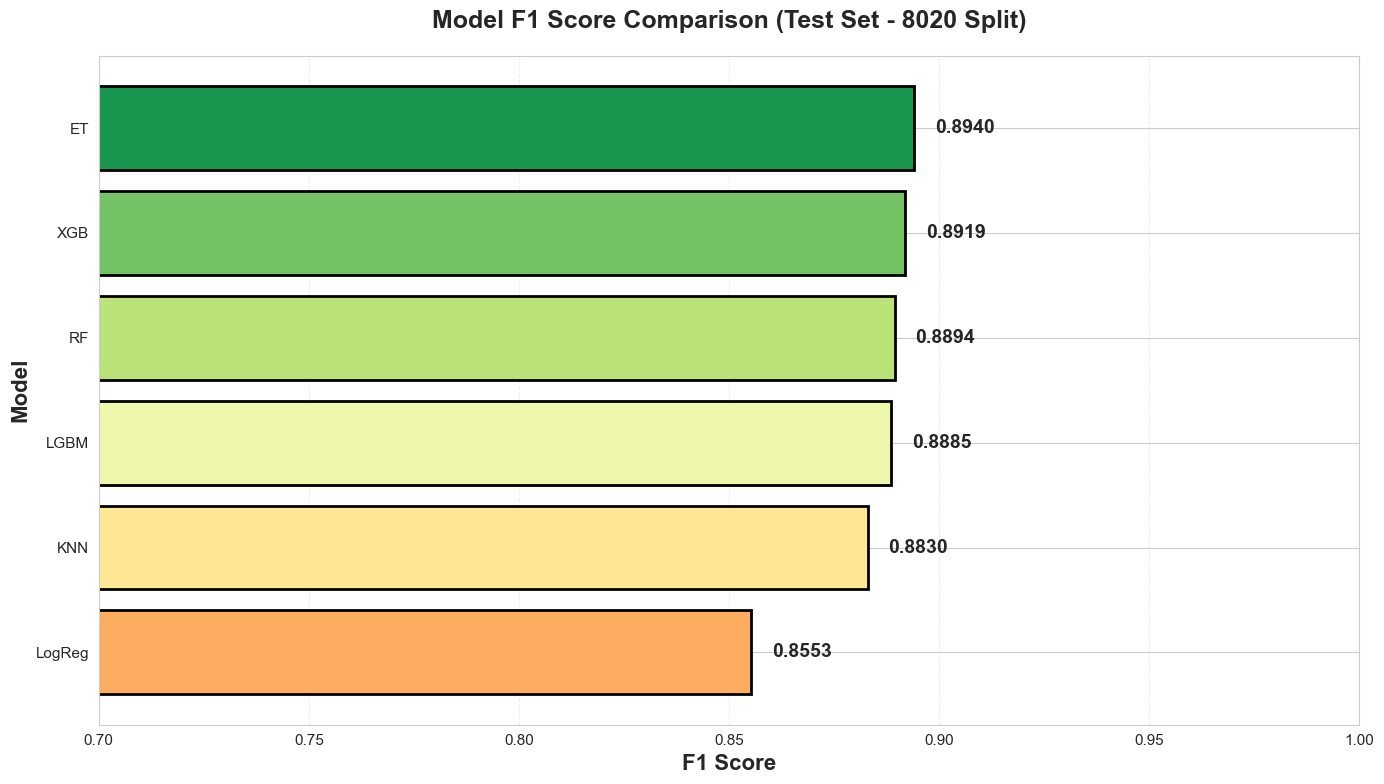

✅ F1 Score plot saved


In [7]:
# Individual plot - F1 Score
plt.figure(figsize=(14, 8))

plot_df = df_results.sort_values('f1', ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(plot_df)))
bars = plt.barh(plot_df['Model'], plot_df['f1'], color=colors, edgecolor='black', linewidth=2)

plt.xlabel('F1 Score', fontweight='bold', fontsize=16)
plt.ylabel('Model', fontweight='bold', fontsize=16)
plt.title('Model F1 Score Comparison (Test Set - 8020 Split)', fontweight='bold', fontsize=18, pad=20)
plt.xlim(0.7, 1.0)
plt.grid(axis='x', alpha=0.3, linestyle='--')

for i, (bar, val) in enumerate(zip(bars, plot_df['f1'])):
    plt.text(val + 0.005, i, f'{val:.4f}', va='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/metrics_part2_f1_score.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ F1 Score plot saved')

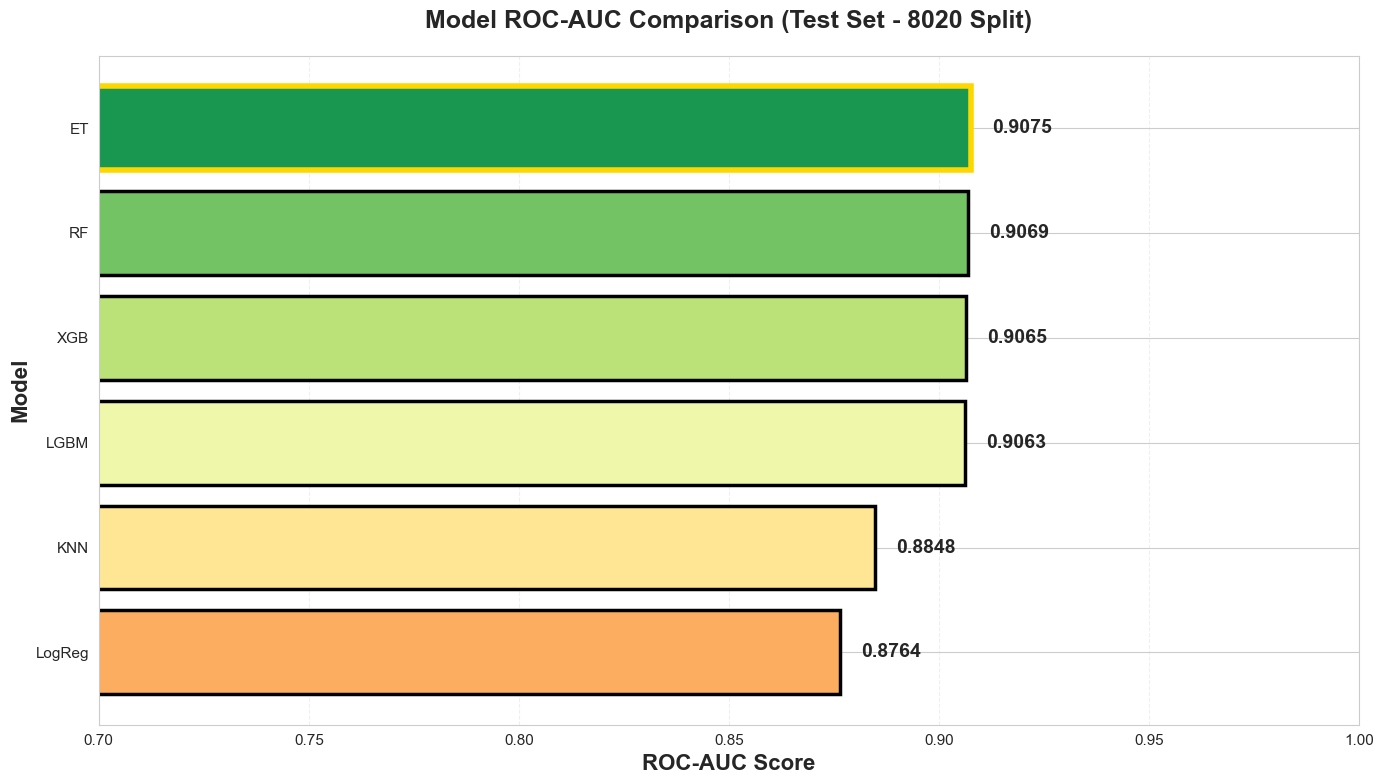

✅ ROC-AUC plot saved


In [8]:
# Individual plot - ROC-AUC (most important metric)
plt.figure(figsize=(14, 8))

plot_df = df_results.sort_values('roc_auc', ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(plot_df)))
bars = plt.barh(plot_df['Model'], plot_df['roc_auc'], color=colors, edgecolor='black', linewidth=2.5)

plt.xlabel('ROC-AUC Score', fontweight='bold', fontsize=16)
plt.ylabel('Model', fontweight='bold', fontsize=16)
plt.title('Model ROC-AUC Comparison (Test Set - 8020 Split)', fontweight='bold', fontsize=18, pad=20)
plt.xlim(0.7, 1.0)
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Highlight best model
best_idx = plot_df['roc_auc'].idxmax()
best_bar_pos = list(plot_df.index).index(best_idx)
bars[best_bar_pos].set_edgecolor('gold')
bars[best_bar_pos].set_linewidth(4)

for i, (bar, val) in enumerate(zip(bars, plot_df['roc_auc'])):
    plt.text(val + 0.005, i, f'{val:.4f}', va='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/metrics_part2_roc_auc.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ ROC-AUC plot saved')

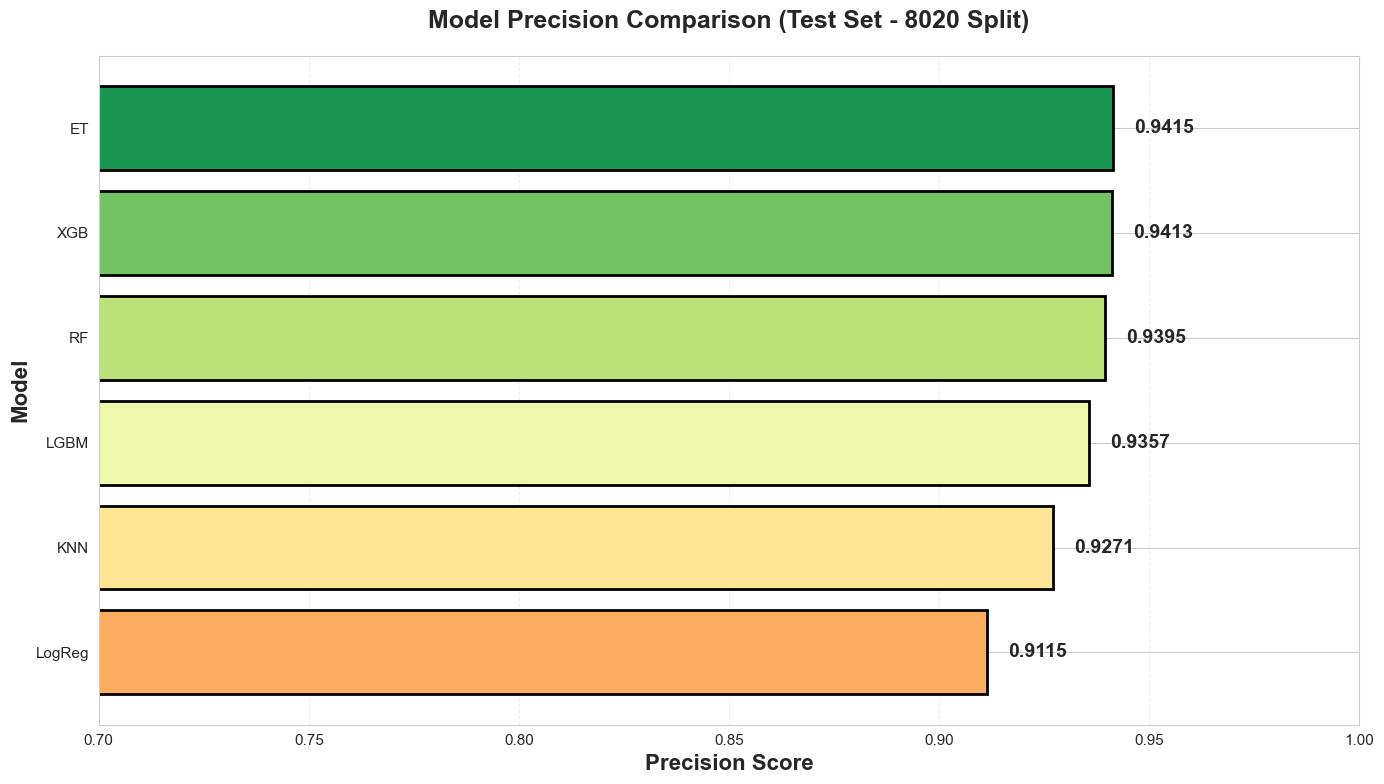

✅ Precision plot saved


In [9]:
# Individual plot - Precision
plt.figure(figsize=(14, 8))

plot_df = df_results.sort_values('precision', ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(plot_df)))
bars = plt.barh(plot_df['Model'], plot_df['precision'], color=colors, edgecolor='black', linewidth=2)

plt.xlabel('Precision Score', fontweight='bold', fontsize=16)
plt.ylabel('Model', fontweight='bold', fontsize=16)
plt.title('Model Precision Comparison (Test Set - 8020 Split)', fontweight='bold', fontsize=18, pad=20)
plt.xlim(0.7, 1.0)
plt.grid(axis='x', alpha=0.3, linestyle='--')

for i, (bar, val) in enumerate(zip(bars, plot_df['precision'])):
    plt.text(val + 0.005, i, f'{val:.4f}', va='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/metrics_part2_precision.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ Precision plot saved')

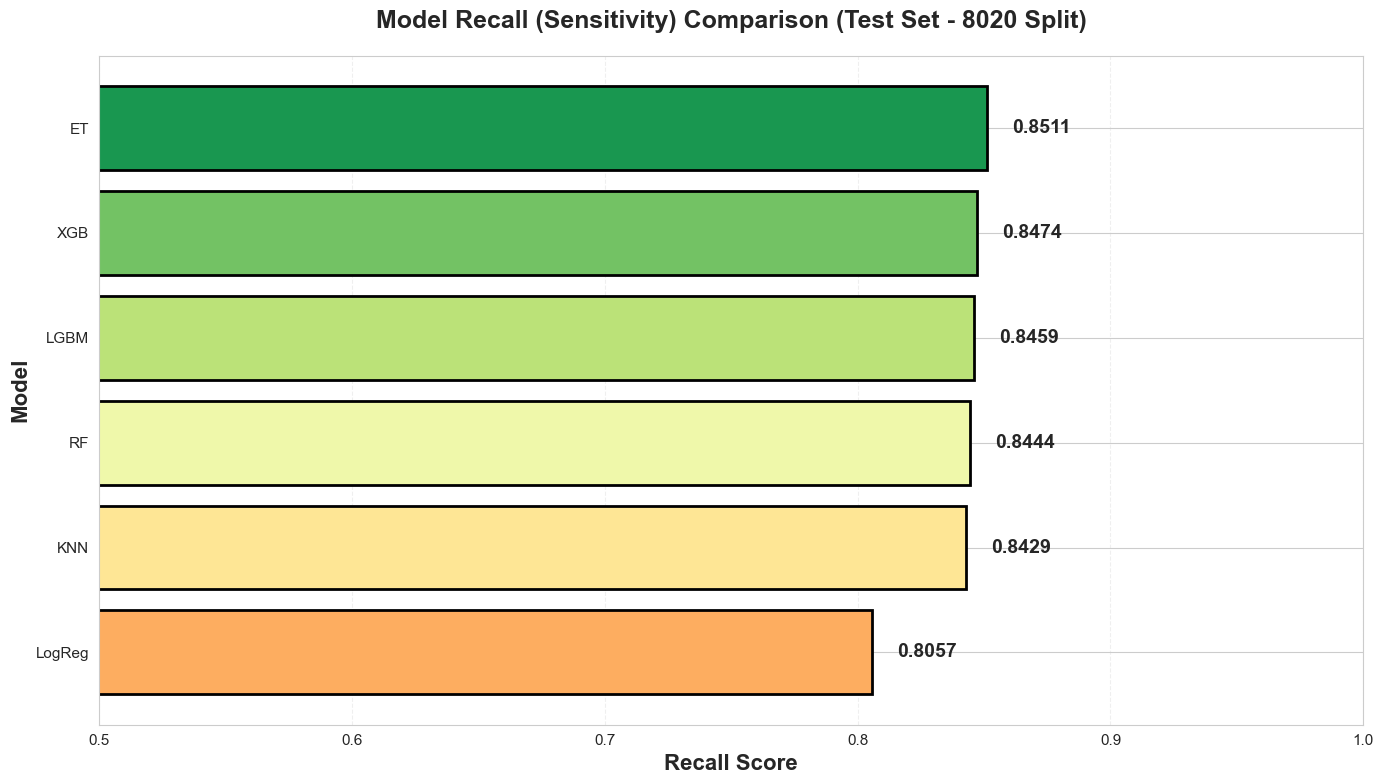

✅ Recall plot saved


In [10]:
# Individual plot - Recall
plt.figure(figsize=(14, 8))

plot_df = df_results.sort_values('recall', ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(plot_df)))
bars = plt.barh(plot_df['Model'], plot_df['recall'], color=colors, edgecolor='black', linewidth=2)

plt.xlabel('Recall Score', fontweight='bold', fontsize=16)
plt.ylabel('Model', fontweight='bold', fontsize=16)
plt.title('Model Recall (Sensitivity) Comparison (Test Set - 8020 Split)', fontweight='bold', fontsize=18, pad=20)
plt.xlim(0.5, 1.0)
plt.grid(axis='x', alpha=0.3, linestyle='--')

for i, (bar, val) in enumerate(zip(bars, plot_df['recall'])):
    plt.text(val + 0.01, i, f'{val:.4f}', va='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/metrics_part2_recall.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ Recall plot saved')

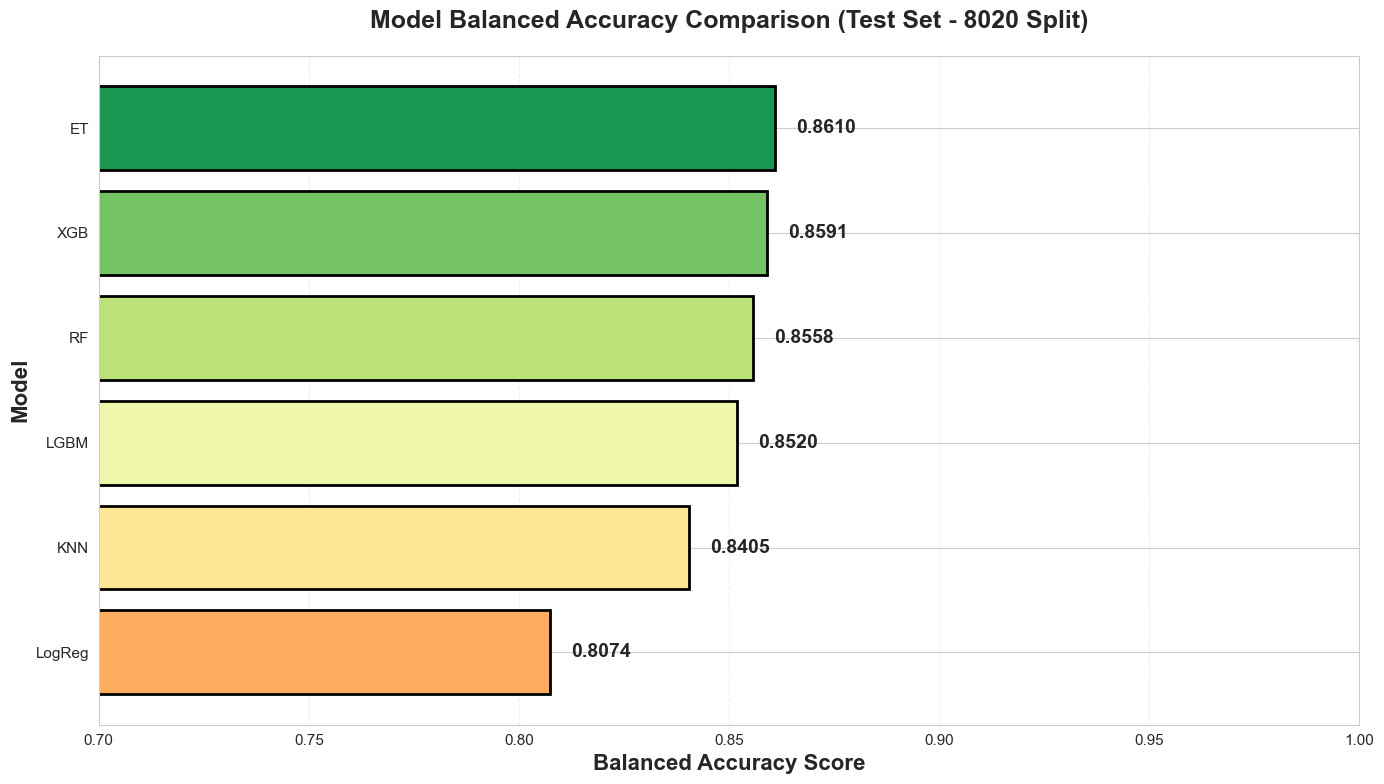

✅ Balanced Accuracy plot saved


In [11]:
# Individual plot - Balanced Accuracy
plt.figure(figsize=(14, 8))

plot_df = df_results.sort_values('balanced_accuracy', ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(plot_df)))
bars = plt.barh(plot_df['Model'], plot_df['balanced_accuracy'], color=colors, edgecolor='black', linewidth=2)

plt.xlabel('Balanced Accuracy Score', fontweight='bold', fontsize=16)
plt.ylabel('Model', fontweight='bold', fontsize=16)
plt.title('Model Balanced Accuracy Comparison (Test Set - 8020 Split)', fontweight='bold', fontsize=18, pad=20)
plt.xlim(0.7, 1.0)
plt.grid(axis='x', alpha=0.3, linestyle='--')

for i, (bar, val) in enumerate(zip(bars, plot_df['balanced_accuracy'])):
    plt.text(val + 0.005, i, f'{val:.4f}', va='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/metrics_part2_balanced_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ Balanced Accuracy plot saved')

## 5. Individual ROC-AUC Curves

In [12]:
# Load predictions from saved CSV files
test_predictions = {}
test_probabilities = {}

print("Loading prediction files...")
for model_name in model_names:
    try:
        pred_file = f'../output/models/hypertuning/predictions_{model_name}_8020.csv'
        pred_df = pd.read_csv(pred_file)
        test_predictions[model_name] = pred_df['y_pred'].values
        test_probabilities[model_name] = pred_df['y_proba'].values
        print(f'✅ Loaded predictions for {model_name}')
    except Exception as e:
        print(f'❌ Could not load predictions for {model_name}: {e}')
        test_predictions[model_name] = None
        test_probabilities[model_name] = None

print('\n✅ Predictions loaded')

Loading prediction files...
✅ Loaded predictions for LogReg
✅ Loaded predictions for KNN
✅ Loaded predictions for RF
✅ Loaded predictions for ET
✅ Loaded predictions for XGB
✅ Loaded predictions for LGBM

✅ Predictions loaded


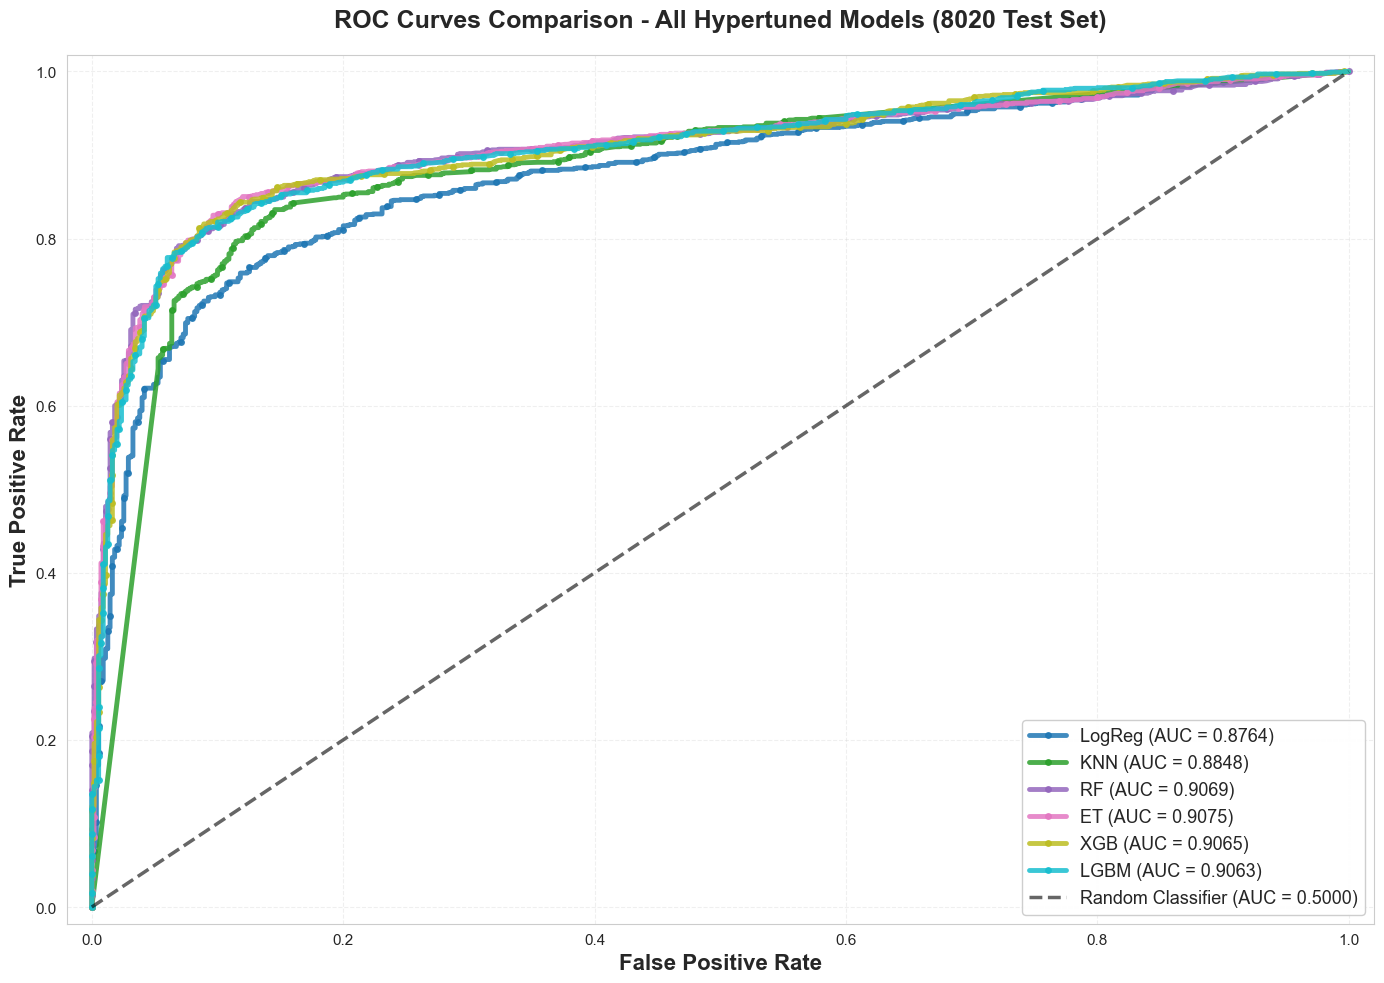

✅ Combined ROC curves plot saved


In [13]:
# Create combined ROC curve comparison plot
plt.figure(figsize=(14, 10))

model_list = list(models.keys())
colors_roc = plt.cm.tab10(np.linspace(0, 1, len(model_list)))

for idx, model_name in enumerate(model_list):
    if test_probabilities[model_name] is not None:
        fpr, tpr, _ = roc_curve(y_test, test_probabilities[model_name])
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, color=colors_roc[idx], lw=3.5, 
                label=f'{model_name} (AUC = {roc_auc:.4f})', alpha=0.85, marker='o', markersize=4, markevery=10)

plt.plot([0, 1], [0, 1], 'k--', lw=2.5, alpha=0.6, label='Random Classifier (AUC = 0.5000)')
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate', fontweight='bold', fontsize=16)
plt.ylabel('True Positive Rate', fontweight='bold', fontsize=16)
plt.title('ROC Curves Comparison - All Hypertuned Models (8020 Test Set)', fontweight='bold', fontsize=18, pad=20)
plt.legend(loc='lower right', fontsize=13, framealpha=0.95)
plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('../figures/metrics_part2_roc_curves_combined.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ Combined ROC curves plot saved')

## 6. Individual Confusion Matrices

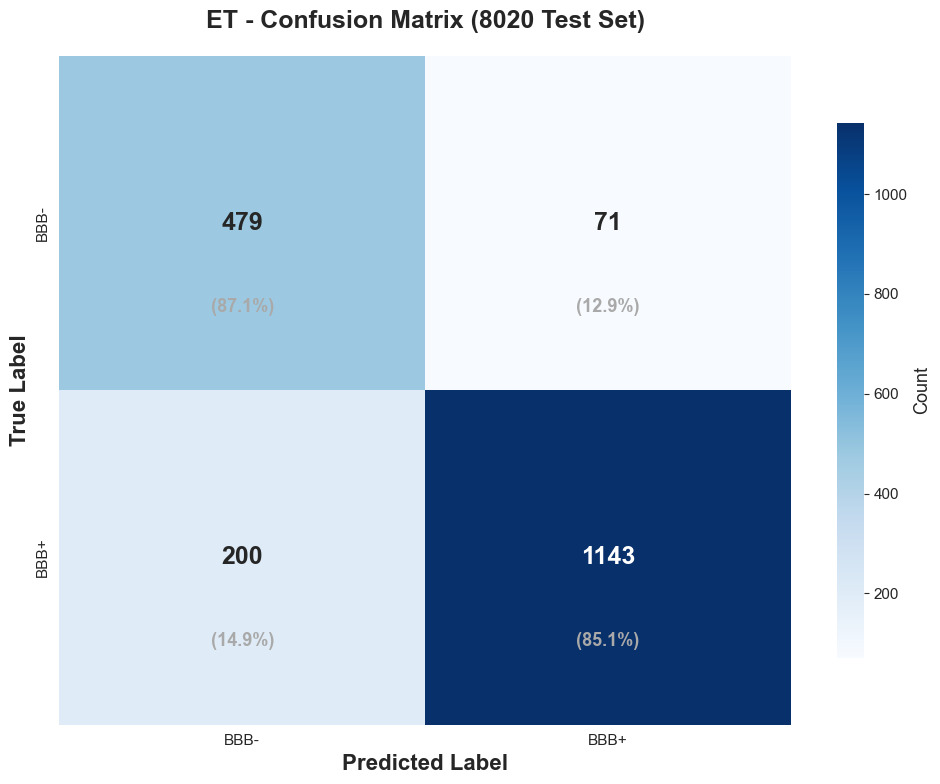

✅ Confusion matrix for ET saved


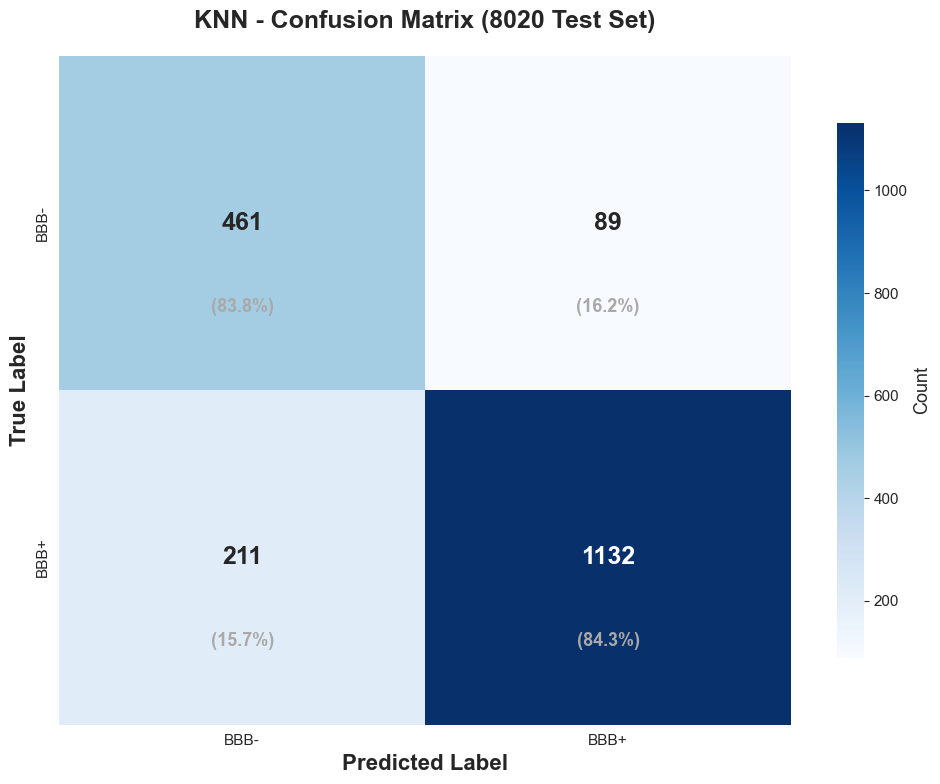

✅ Confusion matrix for KNN saved


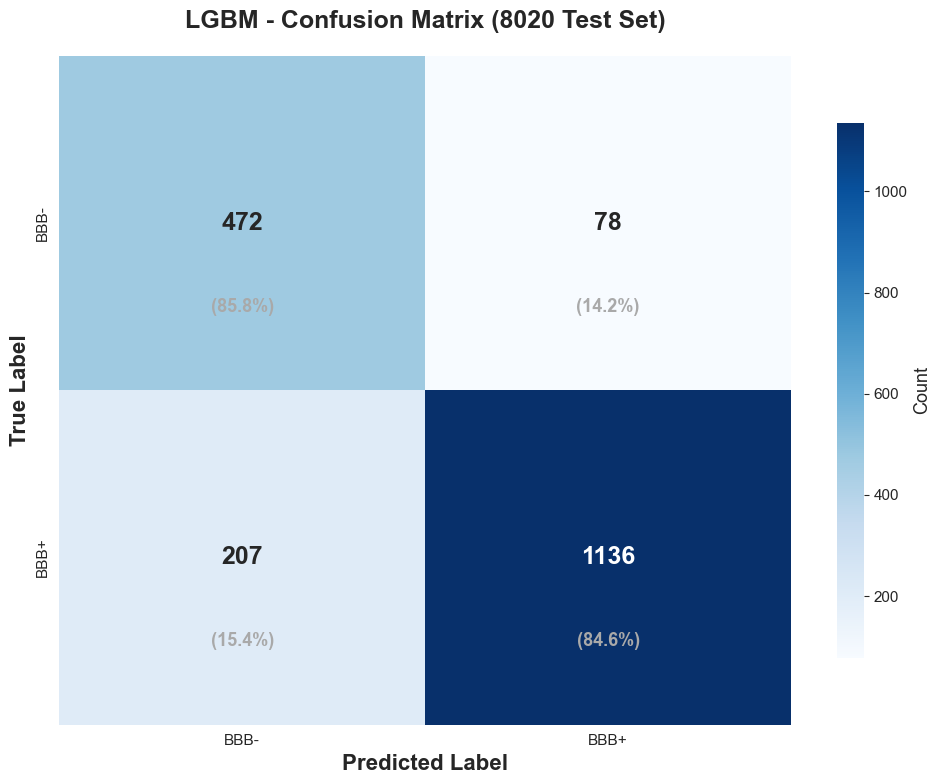

✅ Confusion matrix for LGBM saved


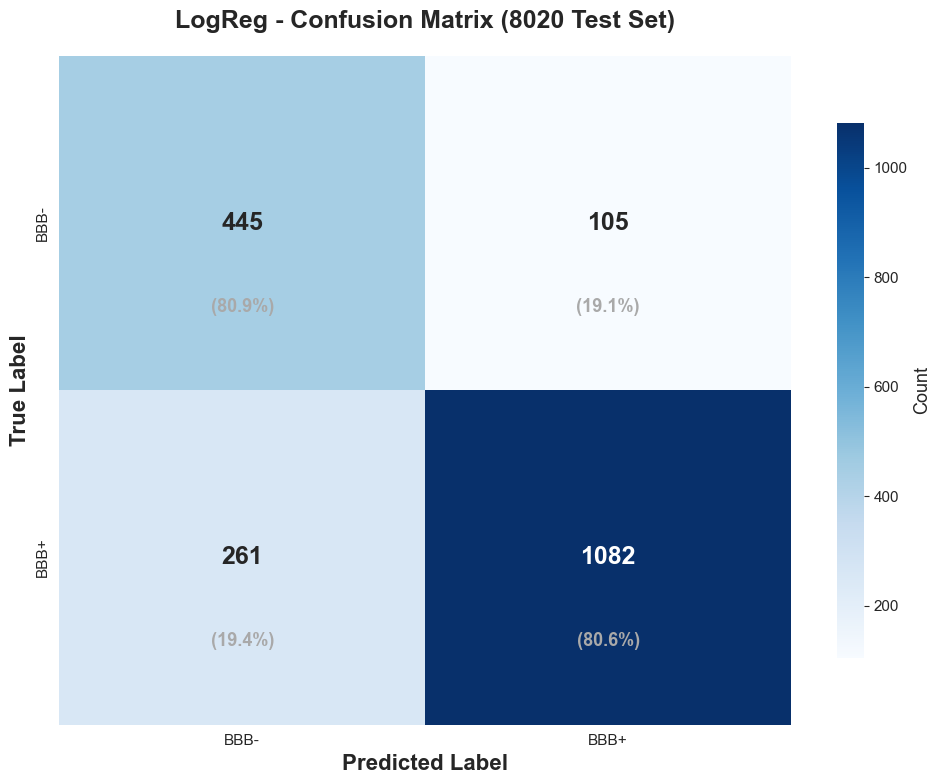

✅ Confusion matrix for LogReg saved


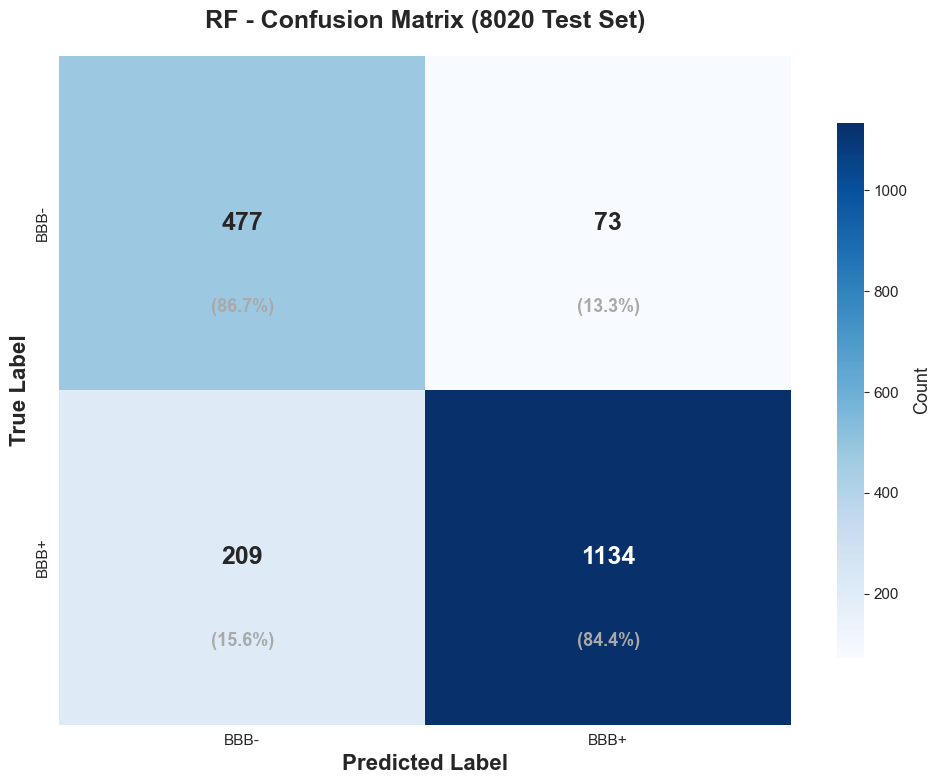

✅ Confusion matrix for RF saved


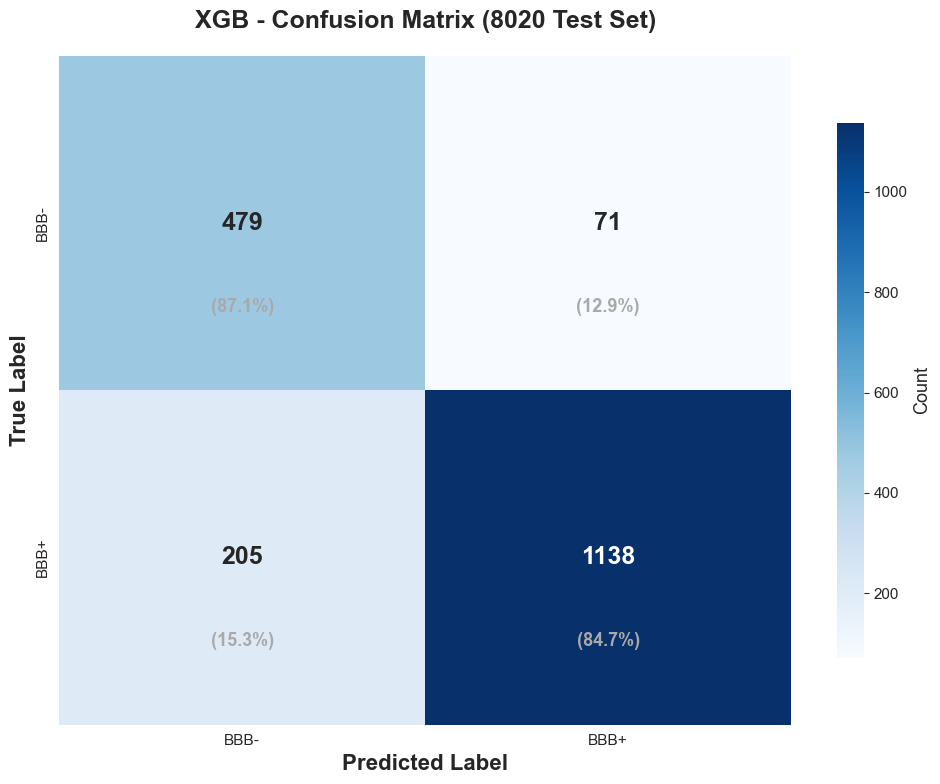

✅ Confusion matrix for XGB saved

✅ All confusion matrices created


In [14]:
# Create individual confusion matrices for each model
for model_name in sorted(model_list):
    if test_predictions[model_name] is not None:
        plt.figure(figsize=(10, 8))
        
        cm = confusion_matrix(y_test, test_predictions[model_name])
        
        # Create heatmap with larger font
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                    annot_kws={'size': 18, 'weight': 'bold'},
                    xticklabels=['BBB-', 'BBB+'],
                    yticklabels=['BBB-', 'BBB+'],
                    cbar_kws={'label': 'Count', 'shrink': 0.8})
        
        plt.xlabel('Predicted Label', fontweight='bold', fontsize=16)
        plt.ylabel('True Label', fontweight='bold', fontsize=16)
        plt.title(f'{model_name} - Confusion Matrix (8020 Test Set)', fontweight='bold', fontsize=18, pad=20)
        
        # Add percentages below the count
        cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        for i in range(2):
            for j in range(2):
                text = plt.text(j + 0.5, i + 0.75, f'({cm_percent[i, j]*100:.1f}%)',
                              ha='center', va='center', color='darkgray', fontsize=13, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(f'../figures/metrics_part2_confusion_matrix_{model_name}.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f'✅ Confusion matrix for {model_name} saved')

print('\n✅ All confusion matrices created')

## 7. Trial Stability Analysis (Multiple Random Splits)

In [15]:
# Load trial results if available
try:
    df_trials = pd.read_csv('../output/models/hypertuning/trials_results_10runs.csv')
    comparison_trials = pd.read_csv('../output/models/hypertuning/trials_summary_vs_single.csv')
    
    print("="*100)
    print("TRIAL RESULTS: 5 RANDOM TRAIN-TEST SPLITS WITH BEST HYPERPARAMETERS")
    print("="*100)
    
    # Show average performance across trials
    n_trials = df_trials['trial'].max()
    
    summary_trials = df_trials.groupby('model').agg({
        'accuracy': ['mean', 'std'],
        'balanced_accuracy': ['mean', 'std'],
        'f1': ['mean', 'std'],
        'roc_auc': ['mean', 'std'],
        'mcc': ['mean', 'std']
    }).round(4)
    
    print(f"\n✅ Average Performance Across {n_trials} Trials (Mean ± Std):\n")
    display(summary_trials)
    
    print("\n" + "="*100)
    print("SINGLE RUN vs TRIAL AVERAGE COMPARISON")
    print("="*100 + "\n")
    display(comparison_trials)
    
except Exception as e:
    print(f'⚠️ Trial results not available: {e}')
    df_trials = None
    comparison_trials = None

⚠️ Trial results not available: [Errno 2] No such file or directory: '../output/models/hypertuning/trials_results_10runs.csv'


In [ ]:
# Visualize trial stability - Balanced Accuracy across trials
if df_trials is not None:
    plt.figure(figsize=(14, 8))
    
    models_sorted = df_trials.groupby('model')['balanced_accuracy'].mean().sort_values(ascending=True).index.tolist()
    
    for model_name in models_sorted:
        model_trials = df_trials[df_trials['model'] == model_name].sort_values('trial')
        plt.plot(model_trials['trial'], model_trials['balanced_accuracy'], 
                marker='o', linewidth=3, markersize=10, label=model_name, alpha=0.8)
    
    plt.xlabel('Trial Number', fontweight='bold', fontsize=16)
    plt.ylabel('Balanced Accuracy', fontweight='bold', fontsize=16)
    plt.title('Model Stability Across 5 Random Train-Test Splits', fontweight='bold', fontsize=18, pad=20)
    plt.xticks(range(1, int(n_trials) + 1), fontsize=13)
    plt.yticks(fontsize=13)
    plt.legend(fontsize=13, loc='best', framealpha=0.95)
    plt.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    
    plt.savefig('../figures/metrics_part2_trial_stability.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print('✅ Trial stability plot saved')

In [ ]:
# Trial stability - ROC-AUC mean and std comparison
if df_trials is not None:
    plt.figure(figsize=(14, 8))
    
    trial_means = df_trials.groupby('model')['roc_auc'].mean().sort_values(ascending=True)
    trial_stds = df_trials.groupby('model')['roc_auc'].std()
    
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(trial_means)))
    bars = plt.barh(range(len(trial_means)), trial_means.values, xerr=trial_stds.values, 
                    color=colors, capsize=8, edgecolor='black', linewidth=2, alpha=0.8)
    
    plt.yticks(range(len(trial_means)), trial_means.index, fontsize=14)
    plt.xlabel('ROC-AUC Score (Mean ± Std across 5 trials)', fontweight='bold', fontsize=16)
    plt.ylabel('Model', fontweight='bold', fontsize=16)
    plt.title('Trial Averaging: ROC-AUC Performance Across 5 Random Splits', fontweight='bold', fontsize=18, pad=20)
    plt.xlim(0.7, 1.0)
    plt.grid(axis='x', alpha=0.3, linestyle='--')
    
    for i, (mean, std) in enumerate(zip(trial_means.values, trial_stds.values)):
        plt.text(mean + std + 0.01, i, f'{mean:.4f}±{std:.4f}', va='center', fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('../figures/metrics_part2_trial_roc_auc.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print('✅ Trial ROC-AUC plot saved')

## 8. Summary and Key Findings

In [ ]:
# Generate comprehensive summary
print('='*100)
print('📊 COMPREHENSIVE MODEL PERFORMANCE SUMMARY (8020 SPLIT - HYPERTUNED MODELS)')
print('='*100)

# Best model by each metric
metrics_to_summarize = ['accuracy', 'balanced_accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'mcc']
print('\n🏆 Best Performing Models by Metric:\n')
for metric in metrics_to_summarize:
    best_idx = df_results[metric].idxmax()
    best_model = df_results.loc[best_idx]
    print(f'{metric:20} → {best_model["Model"]:10} ({best_model[metric]:.4f})')

# Overall best model (by average rank)
print('\n🥇 Overall Best Model (by average rank across all metrics):')
ranks = pd.DataFrame()
for metric in metrics_to_summarize:
    ranks[metric] = df_results[metric].rank(ascending=False)
ranks['Average_Rank'] = ranks.mean(axis=1)
ranks['Model'] = df_results['Model'].values
best_overall = ranks.loc[ranks['Average_Rank'].idxmin()]
print(f"\n   {best_overall['Model']} (Average Rank: {best_overall['Average_Rank']:.2f})")

# Model insights
print('\n📈 Key Model Insights:')
print(f"  • Best ROC-AUC: {df_results.loc[df_results['roc_auc'].idxmax()]['Model']} ({df_results['roc_auc'].max():.4f})")
print(f"  • Best F1-Score: {df_results.loc[df_results['f1'].idxmax()]['Model']} ({df_results['f1'].max():.4f})")
print(f"  • Best Balanced Accuracy: {df_results.loc[df_results['balanced_accuracy'].idxmax()]['Model']} ({df_results['balanced_accuracy'].max():.4f})")
print(f"  • Best Precision: {df_results.loc[df_results['precision'].idxmax()]['Model']} ({df_results['precision'].max():.4f})")
print(f"  • Best Recall: {df_results.loc[df_results['recall'].idxmax()]['Model']} ({df_results['recall'].max():.4f})")

if df_trials is not None:
    print(f"\n🔄 Trial Stability (across {int(n_trials)} random splits):")
    for model_name in df_results['Model'].values:
        model_trials = df_trials[df_trials['model'] == model_name]
        mean_roc = model_trials['roc_auc'].mean()
        std_roc = model_trials['roc_auc'].std()
        print(f"  • {model_name:10}: ROC-AUC = {mean_roc:.4f} ± {std_roc:.4f}")

print('\n' + '='*100)
print('✅ Analysis Complete!')
print('='*100)

print('\n📁 Generated Visualizations:')
print('  ✓ metrics_part2_accuracy.png')
print('  ✓ metrics_part2_f1_score.png')
print('  ✓ metrics_part2_roc_auc.png')
print('  ✓ metrics_part2_precision.png')
print('  ✓ metrics_part2_recall.png')
print('  ✓ metrics_part2_balanced_accuracy.png')
print('  ✓ metrics_part2_roc_curves_combined.png')
print('  ✓ metrics_part2_confusion_matrix_[MODEL].png (6 individual models)')
print('  ✓ metrics_part2_trial_stability.png')
print('  ✓ metrics_part2_trial_roc_auc.png')
print('\nAll files saved to: ../figures/')